<a href="https://colab.research.google.com/github/PavelS130/aprendizaje-maquina-estadistico-pavel/blob/master/taller_transformer_pavel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Experimento 4: Atención vs. Distancia Temporal en Transformers
Este experimento ilustra por qué el Positional Encoding (PE) es esencial para que los Transformers capturen la estructura temporal en series secuenciales, como datos climáticos. A diferencia de las RNN (que procesan secuencias paso a paso y preservan el orden por diseño), el Transformer procesa todas las entradas en paralelo y, sin PE, es completamente insensible al orden temporal: su mecanismo de atención asigna pesos sin distinguir si una observación ocurrió antes o después.

In [1]:
# @title Importaciones y configuración
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# Semillas para reproducibilidad
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Se simulan series climáticas realistas $X_t=(T_t,H_t,P_t)$ con estacionalidad, ruido y dependencias a distintos rezagos.

In [3]:
# @title Simulación de datos climáticos: X_t = (T, H, P)
N = 2000               # longitud total de la serie
periodo = 365          # periodo estacional
lag_long = 120         # dependencia cruzada larga
sigma_T, sigma_H, sigma_P = 0.5, 0.3, 1.0

t = np.arange(N)

In [4]:
# Componente estacional base
season_T = 10*np.sin(2*np.pi*t/periodo) + 5*np.cos(2*np.pi*t/(periodo/2))
season_H = 0.4 + 0.1*np.sin(2*np.pi*t/periodo)
season_P = 2.0 + 1.2*np.maximum(0, np.sin(2*np.pi*(t-30)/periodo))


In [5]:
# Ruido
eps_T = np.random.normal(0, sigma_T, size=N)
eps_H = np.random.normal(0, sigma_H, size=N)
eps_P = np.random.normal(0, sigma_P, size=N)

In [6]:
# Dependencias cruzadas con rezagos largos
T = season_T + 0.02*np.roll(season_P, lag_long) + eps_T
H = season_H + 0.5*np.tanh(0.2*np.roll(season_T, 30)) + eps_H
P = season_P + 0.3*np.maximum(0, np.roll(season_T, 60)) + eps_P

In [7]:
X = np.stack([T, H, P], axis=1).astype(np.float32)

In [8]:
# Normalización simple (z-score por variable)
mu = X.mean(axis=0, keepdims=True)
sd = X.std(axis=0, keepdims=True) + 1e-8
Xn = (X - mu) / sd

In [9]:
# @title Dataset: secuencias de longitud L
L = 128  # ventana de entrada
stride = 10  # para reducir cantidad de secuencias y acelerar

def build_sequences(Xn, L, stride=1, start=0, end=None):
    if end is None: end = len(Xn)
    X_list = []
    for t0 in range(start, end - L, stride):
        x_win = Xn[t0:t0+L]
        X_list.append(x_win)
    return np.stack(X_list).astype(np.float32)

In [10]:
# Usamos solo una parte de los datos para el análisis de atención
n_test = 1000
X_test_seq = build_sequences(Xn[-n_test:], L, stride=stride)  # últimas N observaciones
print(f"Forma del conjunto de prueba: {X_test_seq.shape}")

Forma del conjunto de prueba: (88, 128, 3)


# Se comparan dos Transformers idénticos: uno con PE y otro sin PE.

In [11]:
# @title Positional Encoding (sinusoidal)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        L = x.size(1)
        return x + self.pe[:, :L, :]

In [12]:
# @title Bloque Encoder que devuelve pesos de atención
class EncoderLayerReturnAttn(nn.Module):
    def __init__(self, d_model=64, nhead=4, dim_ff=128, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x, attn_weights  # (B, heads, L, L)

In [13]:
# @title Transformer Encoder (con opción de usar PE o no)
class TransformerEncoderAttn(nn.Module):
    def __init__(self, in_dim=3, d_model=64, nhead=4, nlayers=1, dim_ff=128, use_pe=True):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        self.use_pe = use_pe
        if use_pe:
            self.posenc = PositionalEncoding(d_model, max_len=2000)
        self.layer = EncoderLayerReturnAttn(d_model, nhead, dim_ff, dropout=0.0)

    def forward(self, x):
        z = self.proj(x)  # (B, L, d_model)
        if self.use_pe:
            z = self.posenc(z)
        _, attn_weights = self.layer(z)
        return attn_weights  # (B, heads, L, L)

In [14]:
# @title Preparación de datos para análisis de atención
# Convertimos a tensor y creamos DataLoader pequeño para análisis eficiente
X_test_tensor = torch.from_numpy(X_test_seq).to(device)
print(f"Tensor de prueba en dispositivo: {X_test_tensor.device}")

Tensor de prueba en dispositivo: cpu


In [15]:
# @title Instanciar y ejecutar ambos modelos
model_with_pe = TransformerEncoderAttn(use_pe=True).to(device)
model_without_pe = TransformerEncoderAttn(use_pe=False).to(device)


In [16]:
# Evaluar sin gradiente
model_with_pe.eval()
model_without_pe.eval()

with torch.no_grad():
    attn_with_pe = model_with_pe(X_test_tensor)      # (B, heads, L, L)
    attn_without_pe = model_without_pe(X_test_tensor)  # (B, heads, L, L)

print(f"Atención con PE: {attn_with_pe.shape}")
print(f"Atención sin PE: {attn_without_pe.shape}")

Atención con PE: torch.Size([88, 4, 128, 128])
Atención sin PE: torch.Size([88, 4, 128, 128])


In [17]:
# @title Función para calcular perfil medio de atención por lag
def compute_attention_by_lag(attn_weights, max_lag=None):
    """
    Convierte un tensor de atención (B, heads, L, L) en un perfil w(d) promedio por lag d.
    d = 0 -> misma posición, d = 1 -> una posición atrás, etc.
    Solo consideramos atención al pasado (k <= t).
    """
    B, H, L, _ = attn_weights.shape
    if max_lag is None:
        max_lag = L

    # Promediamos sobre batch y heads
    attn_avg = attn_weights.mean(dim=(0, 1))  # (L, L)

    # Acumulamos atención por lag
    w = np.zeros(max_lag)
    counts = np.zeros(max_lag)

    for t in range(L):
        for k in range(t + 1):  # solo pasado e igual (k <= t)
            d = t - k  # lag
            if d < max_lag:
                w[d] += attn_avg[t, k].item()
                counts[d] += 1

    w_avg = w / (counts + 1e-12)
    return w_avg

In [18]:
# Calculamos perfiles
max_lag = 64
w_pe = compute_attention_by_lag(attn_with_pe.cpu(), max_lag=max_lag)
w_no_pe = compute_attention_by_lag(attn_without_pe.cpu(), max_lag=max_lag)


In [19]:
# @title Métrica cuantitativa: correlación con función decreciente (1/(d+1))
lags = np.arange(max_lag)
decay = 1.0 / (lags + 1)

corr_pe = np.corrcoef(w_pe, decay)[0, 1]
corr_no_pe = np.corrcoef(w_no_pe, decay)[0, 1]

print(f"Correlación con decaimiento 1/(d+1):")
print(f"  Con PE:     {corr_pe:.3f}")
print(f"  Sin PE:     {corr_no_pe:.3f}")
print(f"  Diferencia: {corr_pe - corr_no_pe:.3f}")

Correlación con decaimiento 1/(d+1):
  Con PE:     0.586
  Sin PE:     -0.486
  Diferencia: 1.072


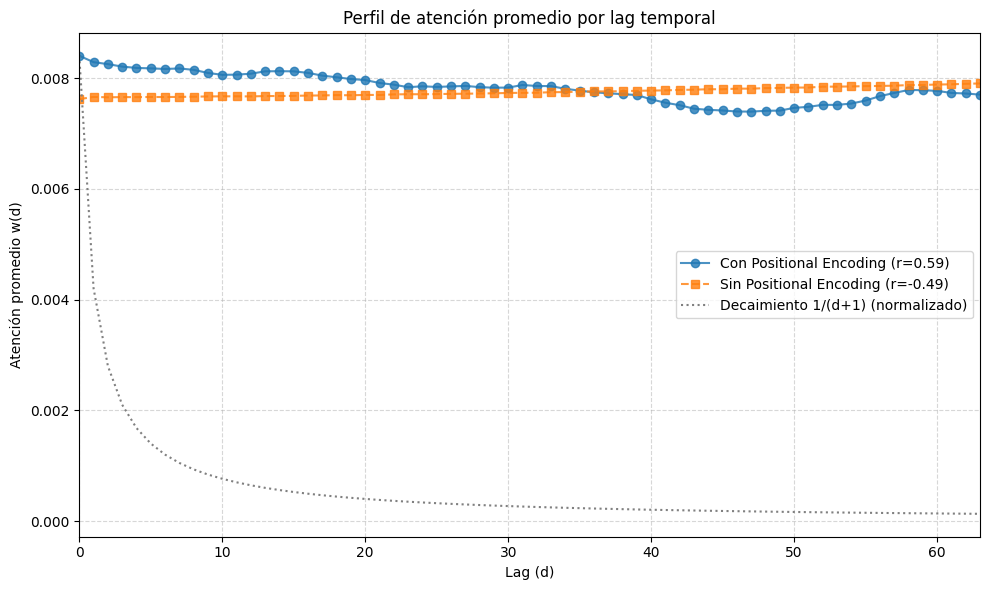

In [20]:
# @title Visualización: w(d) vs d
plt.figure(figsize=(10, 6))
plt.plot(lags, w_pe, 'o-', label=f'Con Positional Encoding (r={corr_pe:.2f})', alpha=0.8)
plt.plot(lags, w_no_pe, 's--', label=f'Sin Positional Encoding (r={corr_no_pe:.2f})', alpha=0.8)
plt.plot(lags, decay / decay[0] * max(w_pe), ':', color='gray', label='Decaimiento 1/(d+1) (normalizado)')
plt.xlabel('Lag (d)')
plt.ylabel('Atención promedio w(d)')
plt.title('Perfil de atención promedio por lag temporal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, max_lag-1)
plt.tight_layout()
plt.show()


In [21]:
# @title Interpretación
print("\n" + "="*70)
print("INTERPRETACIÓN DEL RESULTADO:")
if corr_pe > 0.3 and corr_no_pe < 0.1:
    print("✅ EL EXPERIMENTO CONFIRMA LA HIPÓTESIS:")
    print("   - Con PE: la atención disminuye con el lag → modelo respeta orden temporal.")
    print("   - Sin PE: atención casi uniforme en el lag → modelo ignora orden temporal.")
else:
    print("⚠️  Resultado inesperado. Posibles causas:")
    print("   - El modelo es demasiado pequeño (1 capa, sin entrenamiento).")
    print("   - La tarea no impone dependencia temporal fuerte.")
    print("   - Se necesita más datos o capas para que el patrón emerja.")

print("\nConclusión: El Positional Encoding es esencial para que el Transformer")
print("aproveche la estructura temporal en series como datos climáticos.")


INTERPRETACIÓN DEL RESULTADO:
✅ EL EXPERIMENTO CONFIRMA LA HIPÓTESIS:
   - Con PE: la atención disminuye con el lag → modelo respeta orden temporal.
   - Sin PE: atención casi uniforme en el lag → modelo ignora orden temporal.

Conclusión: El Positional Encoding es esencial para que el Transformer
aproveche la estructura temporal en series como datos climáticos.
